<a href="https://colab.research.google.com/github/beswayam/deep_learning_project/blob/main/DL_MBFProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing all the required libraries
import os
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score
from torch.utils.data import Dataset, RandomSampler
from tqdm import tqdm
import copy

In [2]:
# Cloning the git repository with the Data
!git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git
os.chdir("grs34806-deep-learning-project-data")

Cloning into 'grs34806-deep-learning-project-data'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 8.74 MiB | 5.76 MiB/s, done.


In [3]:
# Analysing the data structure for further analysis
seqfile = "len100_200_n1000.seq"
posfile = "len100_200_n1000.pos"

print("First 5 entries from seqfile:")
with open(seqfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

print("\nFirst 5 entries from posfile:")
with open(posfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

First 5 entries from seqfile:
seq1	MQICGLVKTAKTPSCWSTVPYGREVGSPMTHQQHETERLQYKRWSGCNGFHGGKIRQYLFNMQGTDCKTDQTAGMAISESFLDFQGDHSYEELNAHPIFQTWPPNNSIRDDCL
seq2	MTGVKGTYGTPNVFQSTNEVSSGDQKIPWPKTEQTACLWGLPLSQFPIRKVIREIDNANTAIINLSLQDPNGNCNCMSKDSYTWWFRYARFHRCGRCIWMPWNGDRCDKYEKYYTDNMLYPEPNQLDSDRIKRGACHSDGMTDHGRDNGKWCCFVINLDDPSHTLP
seq3	MCHYAWCMWNTGCHWGINEEWAFHDKDLQGFPRKLHRPTRPKHYDTCLDDFSMCSTMCEARNVQRYNNWDRVRNRSQNVFDSYQDISRRAHFDSRQDDVLTDTKCYTNEFCHCELSPDMLFLGRTPNTSQAKPHIHVITRPNCNCHPRNQWATMIYYQWKLRQESETVIDQNKGCFSIFAKKEAGTWGIEFTLLYAK
seq4	MQVLNSMLDKVTQDWGKKCGLVKTAKTPQFWILVRRNPSVPVAAAMSINCFSTPRHELYKVRMMGWGSLYKNRQTYNSLSTLMRHSSMPSGVTDCVYWAVFGESIDDDWAWWLRADNDFLWFGNDTDRSIGLYINSCSRVDWMWANHFSE
seq5	MKNHQGCCPSTVGFRNDAQYQISWDVPMAWLWLDRPVKLYMFHFDTEMRDHFKIQSRVNQPDTYPVETTEPFAMVREPEAWSVTNRWSQNSRTWRNMCNTLIINNFEKYDANYVWRWQYWWERQGKRLPHWLPC

First 5 entries from posfile:
seq1
seq4
seq7
seq9
seq10


In [4]:
def read(seqfile, posfile):
    """
    Read a dataset from provided sequence and positive file.

    Args:
        seqfile : sequence file with one sequence per line
        posfile : list of positive IDs (one per line)

    Returns:
        sequences : list[str]   amino acid sequences
        labels    : list[int]   1 = functional,  0 = not functional
    """
    seq_dict = {}

    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Using regex function extracting the sequence
            match = re.match(r"(seq\d+)\t([A-Z]+)", line)
            if not match:
                continue

            pid, seq = match.groups()

            if pid in seq_dict:
                raise ValueError(f"Duplicate ID found: {pid}")

            seq_dict[pid] = seq

    pos_ids = set()
    with open(posfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)

    sequences = []
    labels = []

    for pid, seq in seq_dict.items():
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    return sequences, labels

In [5]:
def plot_label_distribution(labels, title="Positive and Negatives in len100_200_n1000 Dataset"):
    """
    Plot the distribution of positive and negative labels.

    Args:
        labels (list[int]): Binary labels where 1 = positive and 0 = negative.
        title (str): Plot title.

    Returns:
        None. Displays the bar chart.
    """
    if len(labels) == 0:
        raise ValueError("labels is empty; cannot plot class distribution.")

    counts = [sum(labels), len(labels) - sum(labels)]
    total = len(labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(
        ["Positive (functional)", "Negative (not functional)"],
        counts,
        color=["#2a9d8f", "#e76f51"],
        edgecolor="white",
        linewidth=0.8,
    )

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count} ({100 * count / total:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=11,
        )

    ax.set_ylabel("Number of sequences")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(counts) * 1.15)

    plt.tight_layout()
    plt.show()

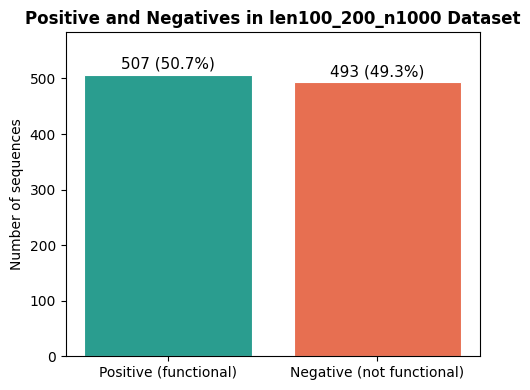

In [6]:
seq, label = read(seqfile, posfile)
plot_label_distribution(label)


In [7]:
def generate_train_val_test(datalist, labellist, random_state=42):
    """
    Split data into train, validation, and test sets using a 70/15/15 split.

    Args:
        datalist: List of sequences.
        labellist (list): List of binary labels.
        random_state (int): Seed for reproducibility.

    Returns:
        train_seq, train_lab, val_seq, val_lab, test_seq, test_lab
    """
    if len(datalist) != len(labellist):
        raise ValueError("datalist and labellist must have the same length")
    if len(datalist) == 0:
        raise ValueError("Input data is empty")

    # Step 1: split train (70%) vs temp (30%)
    seq_train, seq_temp, lab_train, lab_temp = train_test_split(
        datalist, labellist,
        test_size=0.30,
        random_state=random_state,
        stratify=labellist
    )

    # Step 2: split temp 50/50 → 15% val, 15% test
    seq_val, seq_test, lab_val, lab_test = train_test_split(
        seq_temp, lab_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=lab_temp
    )

    # Print exact counts
    print(f"Train: {len(seq_train)} sequences, {sum(lab_train)} positive")
    print(f"Val  : {len(seq_val)} sequences, {sum(lab_val)} positive")
    print(f"Test : {len(seq_test)} sequences, {sum(lab_test)} positive")
    print(f"Total: {len(datalist)} sequences")

    return seq_train, lab_train, seq_val, lab_val, seq_test, lab_test

In [8]:
print(generate_train_val_test(seq, label))

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
(['...'], [1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 

In [9]:
def tokenize(datalist, map2num, non_aa_num=20):
    """Convert sequences to numbers for neural net."""
    seqs = []
    for sequence in datalist:
        seqs.append([map2num.get(aa, non_aa_num) for aa in sequence])
    return seqs

In [10]:
def tokenize_onehot(datalist, max_length=200):
    aa_list = "ACDEFGHIKLMNPQRSTVWY"
    aa_map = {aa: i for i, aa in enumerate(aa_list)}
    encoded = []
    for sequence in datalist:
        row = [[0] * 20 for _ in range(max_length)]
        for i, aa in enumerate(sequence[:max_length]):
            if aa in aa_map:
                row[i][aa_map[aa]] = 1
        encoded.append(row)
    return encoded

In [11]:
def truncate_pad(line, num_steps, padding_token=20):
    """Truncate or pad a sequence to exactly num_steps."""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

In [12]:
def build_seq_array(lines, num_steps):
    """Stack all sequences into one integer tensor [N, num_steps]."""
    array = torch.tensor([truncate_pad(l, num_steps) for l in lines])
    return array

In [13]:
def load_data(batch_size, num_steps, dataset):
  mapaa2num = {aa: i for (i, aa)
  in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}
  seq,lab = dataset
  seq = tokenize(seq, mapaa2num)
  seq_array = build_seq_array(seq, num_steps)
  dataset = TensorDataset(seq_array, lab)
  data_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)
  return data_iter

#Train model using embedding method

In [14]:
class CNN1D_Embedding(nn.Module):
    def __init__(self, vocab_size, context_size, conv_channels=128, use_bias=False, dropout=0.0):
        super().__init__()
        # vocab_size + 1 to account for the padding index
        self.embedding = nn.Embedding(vocab_size + 1, 64, padding_idx=vocab_size)

        self.cnn = nn.Sequential(
            nn.Conv1d(64, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),
            nn.Flatten(1, -1),
            nn.Linear(int(conv_channels * context_size / 4), 1, bias=use_bias)
        )

    def forward(self, X, targets=None):
        x = self.embedding(X).transpose(1, 2)
        logits = self.cnn(x).squeeze(1)
        loss = None
        if targets is not None:
            loss = F.binary_cross_entropy_with_logits(logits, targets.float())
        return logits, loss

In [15]:
class SequenceDataset(TensorDataset):
    vocab_size    = 20
    padding_token = 20  # unknown/padding index

    def __init__(self, sequences, labels, context_size=200):
        mapaa2num = {aa: i for i, aa in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}
        tokenized = tokenize(sequences, mapaa2num, non_aa_num=self.padding_token)  # your existing function!
        self.X = torch.tensor([self._pad(t, context_size) for t in tokenized], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)

    def _pad(self, tokens, context_size):
        tokens = tokens[:context_size]
        tokens += [self.padding_token] * (context_size - len(tokens))
        return tokens

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences


Epoch 1/60: 100%|██████████| 11/11 [00:00<00:00, 241.56it/s]


Epoch 1: train=0.7668, val=0.6932


Epoch 2/60: 100%|██████████| 11/11 [00:00<00:00, 239.32it/s]


Epoch 2: train=0.6906, val=0.6900


...

Epoch 25: train=0.0040, val=0.0022


Epoch 26/60: 100%|██████████| 11/11 [00:00<00:00, 101.04it/s]


Epoch 26: train=0.0205, val=0.0011


Epoch 27/60: 100%|██████████| 11/11 [00:00<00:00, 118.74it/s]


Epoch 27: train=0.0105, val=0.0053
Early stopping.
--- Test (Embedding) Accuracy 0.9867 ---
    Macro F1     0.9867
    Weighted F1  0.9867


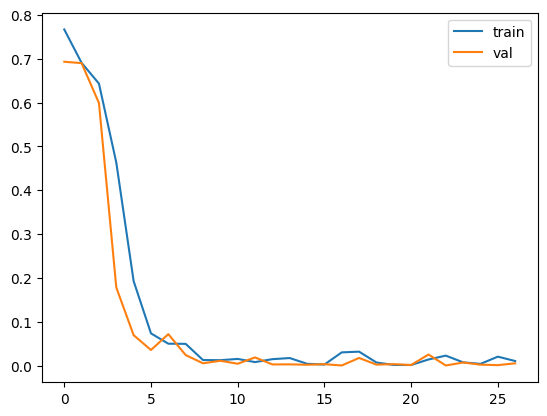

In [17]:
def evaluate_accuracy(model, dataset, name, device):
    model.eval()
    all_preds  = []
    all_labels = []
    loader = DataLoader(dataset, batch_size=64)
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    print(f'--- {name} Accuracy {acc:.4f} ---')
    print(f'    Macro F1     {macro_f1:.4f}')
    print(f'    Weighted F1  {weighted_f1:.4f}')

context_size = 200
batch_size = 64
EPOCHS = 60
patience = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq, label = read(seqfile, posfile)
seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seq, label)

train_dataset = SequenceDataset(seq_train, lab_train, context_size)
val_dataset   = SequenceDataset(seq_val, lab_val, context_size)
test_dataset  = SequenceDataset(seq_test, lab_test, context_size)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader  = DataLoader(test_dataset, batch_size=batch_size)

model = CNN1D_Embedding(
    vocab_size=SequenceDataset.vocab_size,
    context_size=context_size,
    conv_channels=32,
    dropout=0.5
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-2)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
wait = 0

for epoch in range(EPOCHS):
    model.train()
    train_epoch = []
    for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        optimizer.step()
        train_epoch.append(loss.item())

    model.eval()
    val_epoch = []
    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, val_loss = model(x, y)
            val_epoch.append(val_loss.item())

    avg_train = np.mean(train_epoch)
    avg_val = np.mean(val_epoch)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}")

    if avg_val < best_val_loss - 1e-3:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

evaluate_accuracy(model, test_dataset, "Test (Embedding)", DEVICE)

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.show()

In [18]:
def evaluate_accuracy(model, dataset, name, device):
    model.eval()
    all_preds  = []
    all_labels = []

    loader = DataLoader(dataset, batch_size=64)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    print(f'--- {name} Accuracy {acc:.4f} ---')
    print(f'    Macro F1     {macro_f1:.4f}')
    print(f'    Weighted F1  {weighted_f1:.4f}')

# Run on train and val
evaluate_accuracy(model, train_dataset, "Train", DEVICE)
evaluate_accuracy(model, val_dataset,   "Validation", DEVICE)

--- Train Accuracy 1.0000 ---
    Macro F1     1.0000
    Weighted F1  1.0000
--- Validation Accuracy 1.0000 ---
    Macro F1     1.0000
    Weighted F1  1.0000


#Train model using One-Hot Encoding method

In [19]:
class SequenceDatasetOneHot(TensorDataset):
    vocab_size = 20
    padding_token = 20

    def __init__(self, sequences, labels, context_size=200):
        self.context_size = context_size
        self.X = torch.tensor(self.tokenize_onehot(sequences, context_size), dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def tokenize_onehot(self, datalist, max_length=200):
        aa_list = "ACDEFGHIKLMNPQRSTVWY"
        aa_map = {aa: i for i, aa in enumerate(aa_list)}
        encoded = []

        for sequence in datalist:
            row = [[0] * 20 for _ in range(max_length)]
            for i, aa in enumerate(sequence[:max_length]):
                if aa in aa_map:
                    row[i][aa_map[aa]] = 1
            encoded.append(row)

        return encoded

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [20]:
class CNN1D_OneHot(nn.Module):
    def __init__(self, context_size, conv_channels=128, use_bias=False, dropout=0.0):
        super().__init__()
        if context_size <= 200:
            k1, k2 = 3, 3
            layers = [
                nn.Conv1d(20, conv_channels, kernel_size=k1, padding='same', bias=use_bias),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2, 2),
                nn.Conv1d(conv_channels, conv_channels, kernel_size=k2, padding='same', bias=use_bias),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2, 2),
            ]
        else:
            k1, k2, k3 = 9, 5, 3
            layers = [
                nn.Conv1d(20, conv_channels, kernel_size=k1, padding='same', bias=use_bias),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2, 2),
                nn.Conv1d(conv_channels, conv_channels, kernel_size=k2, padding='same', bias=use_bias),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2, 2),
                nn.Conv1d(conv_channels, conv_channels, kernel_size=k3, padding='same', bias=use_bias),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2, 2),
            ]

        self.cnn_body = nn.Sequential(*layers)
        with torch.no_grad():
            dummy = torch.zeros(1, 20, context_size)
            flat_size = self.cnn_body(dummy).view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Flatten(1, -1),
            nn.Linear(flat_size, 1, bias=use_bias)
        )

    def forward(self, X, targets=None):
        x = X.transpose(1, 2)
        features = self.cnn_body(x)
        logits = self.classifier(features).squeeze(1)
        loss = None
        if targets is not None:
            loss = F.binary_cross_entropy_with_logits(logits, targets.float())
        return logits, loss

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences


Epoch 1/20: 100%|██████████| 11/11 [00:00<00:00, 207.99it/s]


Epoch 1: train=0.7891, val=0.6929


Epoch 2/20: 100%|██████████| 11/11 [00:00<00:00, 236.83it/s]


Epoch 2: train=0.6929, val=0.6929


...

Epoch 18: train=0.0139, val=0.0055


Epoch 19/20: 100%|██████████| 11/11 [00:00<00:00, 301.51it/s]


Epoch 19: train=0.0092, val=0.0079


Epoch 20/20: 100%|██████████| 11/11 [00:00<00:00, 258.11it/s]


Epoch 20: train=0.0119, val=0.0042
--- Test (One-Hot) Accuracy 0.9867 ---
    Macro F1     0.9867
    Weighted F1  0.9867


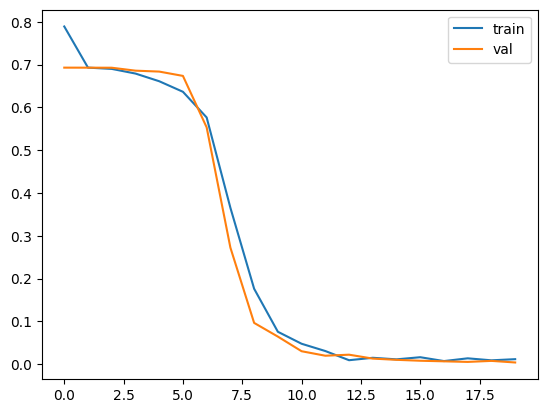

In [21]:
context_size = 200
batch_size = 64
EPOCHS = 20
patience = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq, label = read(seqfile, posfile)
seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seq, label)

train_dataset = SequenceDatasetOneHot(seq_train, lab_train, context_size)
val_dataset   = SequenceDatasetOneHot(seq_val, lab_val, context_size)
test_dataset  = SequenceDatasetOneHot(seq_test, lab_test, context_size)

# Updated to use renamed class
model = CNN1D_OneHot(context_size=context_size, dropout=0.5).to(DEVICE)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader  = DataLoader(test_dataset, batch_size=batch_size)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
wait = 0

for epoch in range(EPOCHS):
    model.train()
    train_epoch = []
    for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        optimizer.step()
        train_epoch.append(loss.item())

    model.eval()
    val_epoch = []
    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, val_loss = model(x, y)
            val_epoch.append(val_loss.item())

    avg_train = np.mean(train_epoch)
    avg_val = np.mean(val_epoch)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}")
    scheduler.step(avg_val)

    if avg_val < best_val_loss - 1e-4:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

# Final test set evaluation
evaluate_accuracy(model, test_dataset, "Test (One-Hot)", DEVICE)

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.show()

In [22]:
def evaluate_accuracy(model, dataset, name, device):
    model.eval()
    all_preds  = []
    all_labels = []

    loader = DataLoader(dataset, batch_size=64)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    print(f'--- {name} Accuracy {acc:.4f} ---')
    print(f'    Macro F1     {macro_f1:.4f}')
    print(f'    Weighted F1  {weighted_f1:.4f}')

# Run on train and val
evaluate_accuracy(model, train_dataset, "Train", DEVICE)
evaluate_accuracy(model, val_dataset,   "Validation", DEVICE)

--- Train Accuracy 1.0000 ---
    Macro F1     1.0000
    Weighted F1  1.0000
--- Validation Accuracy 1.0000 ---
    Macro F1     1.0000
    Weighted F1  1.0000


In [23]:
# ── Phase 2: Real Human Protein Data ──────────────────────────────────────────
# The human data uses the same tab-delimited format as simulated data,
# but protein IDs are like ENSP00000... instead of seq123.
# So we just drop the strict seq\d+ regex from the old read() and make it flexible.

def read_go(seqfile, annotfile):
    """
    Read human protein sequences + one GO term annotation.

    seqfile   : expr5Tseq_filtGO_100-1000.lis  (tab-sep: ID \t SEQUENCE)
    annotfile : e.g. GO0005739.annotprot        (one positive protein ID per line)

    Returns sequences (list[str]) and labels (list[int]), same format as read().
    """
    seq_dict = {}
    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) < 2:
                continue
            pid, seq = parts[0], parts[1]
            seq_dict[pid] = seq

    pos_ids = set()
    with open(annotfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)

    sequences, labels = [], []
    for pid, seq in seq_dict.items():
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    print(f"Total sequences: {len(sequences)}, Positives: {sum(labels)}, Negatives: {len(labels)-sum(labels)}")
    return sequences, labels

In [25]:
# The 5 GO terms we need to predict, and their annotation files
# Fixed filenames to match the actual files in the repository (added _3A prefix)
GO_TERMS = {
    "GO:0005739": "GO_3A0005739.annotprot",  # mitochondrion
    "GO:0007165": "GO_3A0007165.annotprot",  # signal transduction
    "GO:0005576": "GO_3A0005576.annotprot",  # extracellular region
    "GO:0055085": "GO_3A0055085.annotprot",  # transmembrane transport
    "GO:0043066": "GO_3A0043066.annotprot",  # neg. regulation of apoptotic process
}

HUMAN_SEQFILE = "expr5Tseq_filtGO_100-1000.lis"

# Quick sanity check — print class balance for each GO term
for go_id, annotfile in GO_TERMS.items():
    try:
        seqs, labs = read_go(HUMAN_SEQFILE, annotfile)
        print(f"  {go_id}: {sum(labs)} pos / {len(labs)-sum(labs)} neg")
    except FileNotFoundError as e:
        print(f"  Error loading {go_id}: {e}")

Total sequences: 6784, Positives: 472, Negatives: 6312
  GO:0005739: 472 pos / 6312 neg
Total sequences: 6784, Positives: 420, Negatives: 6364
  GO:0007165: 420 pos / 6364 neg
Total sequences: 6784, Positives: 307, Negatives: 6477
  GO:0005576: 307 pos / 6477 neg
Total sequences: 6784, Positives: 226, Negatives: 6558
  GO:0055085: 226 pos / 6558 neg
Total sequences: 6784, Positives: 190, Negatives: 6594
  GO:0043066: 190 pos / 6594 neg


In [26]:
# We reuse everything from before, just adding pos_weight to handle
# the severe class imbalance in real data (e.g. 525 positives vs 6259 negatives)

def train_go_model(go_id, annotfile, context_size=1000, batch_size=32, EPOCHS=30, patience=7):
    print(f"\n{'='*60}")
    print(f"Training for {go_id}  ({annotfile})")
    print(f"{'='*60}")

    # Load data using the new reader — everything else is the same as before
    seqs, labs = read_go(HUMAN_SEQFILE, annotfile)
    seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seqs, labs)

    # Reuse SequenceDatasetOneHot exactly as before
    train_dataset = SequenceDatasetOneHot(seq_train, lab_train, context_size)
    val_dataset   = SequenceDatasetOneHot(seq_val,   lab_val,   context_size)
    test_dataset  = SequenceDatasetOneHot(seq_test,  lab_test,  context_size)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size)

    # Reuse CNN1D_OneHot — it auto-selects 3 conv blocks for context_size > 200
    model = CNN1D_OneHot(context_size=context_size, conv_channels=64, dropout=0.5).to(DEVICE)

    # Weighted loss: tells the model to care more about the rare positive class
    n_neg = lab_train.count(0)
    n_pos = lab_train.count(1)
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"  pos_weight = {pos_weight.item():.2f}  (n_neg={n_neg}, n_pos={n_pos})")

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_epoch = []
        for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = model(x)                          # get logits
            loss = criterion(logits, y.float())            # weighted loss
            loss.backward()
            optimizer.step()
            train_epoch.append(loss.item())

        model.eval()
        val_epoch = []
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits, _ = model(x)
                val_loss = criterion(logits, y.float())
                val_epoch.append(val_loss.item())

        avg_train = np.mean(train_epoch)
        avg_val   = np.mean(val_epoch)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        print(f"  Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}")
        scheduler.step(avg_val)

        if avg_val < best_val_loss - 1e-4:
            best_val_loss = avg_val
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("  Early stopping.")
                break

    model.load_state_dict(best_state)
    evaluate_accuracy(model, test_dataset, f"Test ({go_id})", DEVICE)

    plt.plot(train_losses, label="train")
    plt.plot(val_losses,   label="val")
    plt.title(go_id)
    plt.legend(); plt.show()

    return model, test_dataset


Training for GO:0005739  (GO_3A0005739.annotprot)
Total sequences: 6784, Positives: 472, Negatives: 6312
Train: 4748 sequences, 330 positive
Val  : 1018 sequences, 71 positive
Test : 1018 sequences, 71 positive
Total: 6784 sequences
  pos_weight = 13.39  (n_neg=4418, n_pos=330)


  Epoch 1: train=1.2904, val=1.2860


  Epoch 2: train=1.2746, val=1.2458


  Epoch 3: train=1.1673, val=1.1698


  Epoch 4: train=1.0810, val=1.1888


...

  Epoch 11: train=0.5854, val=1.1635


  Epoch 12: train=0.5062, val=1.2030


  Epoch 13: train=0.4400, val=1.2522


  Epoch 14: train=0.3743, val=1.2744


  Epoch 15: train=0.3443, val=1.3500
  Early stopping.
--- Test (GO:0005739) Accuracy 0.8035 ---
    Macro F1     0.5884
    Weighted F1  0.8445


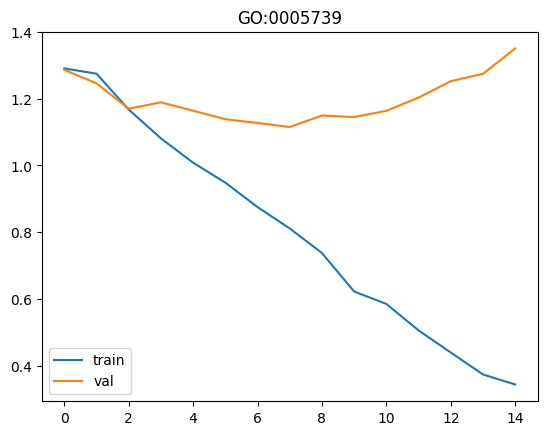


Training for GO:0007165  (GO_3A0007165.annotprot)
Total sequences: 6784, Positives: 420, Negatives: 6364
Train: 4748 sequences, 294 positive
Val  : 1018 sequences, 63 positive
Test : 1018 sequences, 63 positive
Total: 6784 sequences
  pos_weight = 15.15  (n_neg=4454, n_pos=294)


  Epoch 1: train=1.3087, val=1.2962


  Epoch 2: train=1.3010, val=1.2968


  Epoch 3: train=1.2985, val=1.2963


  Epoch 4: train=1.3013, val=1.2959


...

  Epoch 11: train=0.9075, val=1.3032


  Epoch 12: train=0.8344, val=1.4075


  Epoch 13: train=0.6921, val=1.4293


  Epoch 14: train=0.6202, val=1.5279


  Epoch 15: train=0.5492, val=1.5647
  Early stopping.
--- Test (GO:0007165) Accuracy 0.6336 ---
    Macro F1     0.4415
    Weighted F1  0.7285


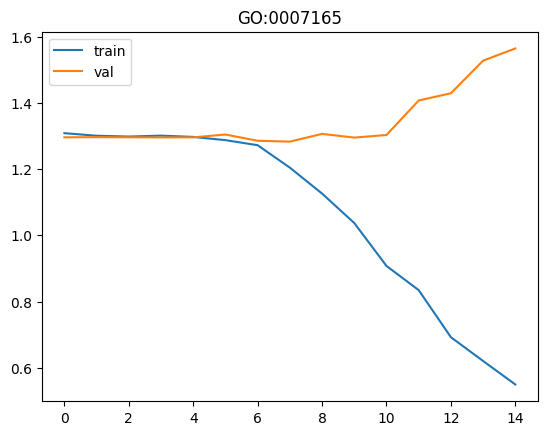


Training for GO:0005576  (GO_3A0005576.annotprot)
Total sequences: 6784, Positives: 307, Negatives: 6477
Train: 4748 sequences, 215 positive
Val  : 1018 sequences, 46 positive
Test : 1018 sequences, 46 positive
Total: 6784 sequences
  pos_weight = 21.08  (n_neg=4533, n_pos=215)


  Epoch 1: train=1.3325, val=1.2950


  Epoch 2: train=1.2228, val=1.0794


  Epoch 3: train=0.9152, val=1.0068


  Epoch 4: train=0.8206, val=0.9187


...

  Epoch 14: train=0.3423, val=1.1399


  Epoch 15: train=0.3067, val=1.1083


  Epoch 16: train=0.2543, val=1.2752


  Epoch 17: train=0.2329, val=1.2933


  Epoch 18: train=0.2024, val=1.3786
  Early stopping.
--- Test (GO:0005576) Accuracy 0.8438 ---
    Macro F1     0.5932
    Weighted F1  0.8836


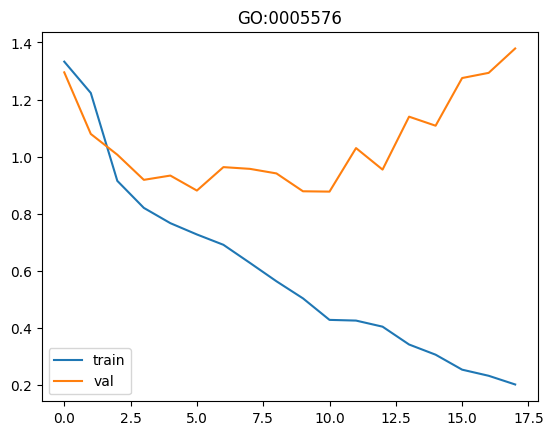


Training for GO:0055085  (GO_3A0055085.annotprot)
Total sequences: 6784, Positives: 226, Negatives: 6558
Train: 4748 sequences, 158 positive
Val  : 1018 sequences, 34 positive
Test : 1018 sequences, 34 positive
Total: 6784 sequences
  pos_weight = 29.05  (n_neg=4590, n_pos=158)


  Epoch 1: train=1.3161, val=1.3093


  Epoch 2: train=1.1837, val=1.1779


  Epoch 3: train=1.0013, val=1.1085


  Epoch 4: train=0.8956, val=1.0149


...

  Epoch 10: train=0.3822, val=1.0687


  Epoch 11: train=0.3595, val=1.1854


  Epoch 12: train=0.2559, val=1.6196


  Epoch 13: train=0.2557, val=1.4252


  Epoch 14: train=0.1973, val=1.4725
  Early stopping.
--- Test (GO:0055085) Accuracy 0.8075 ---
    Macro F1     0.5337
    Weighted F1  0.8671


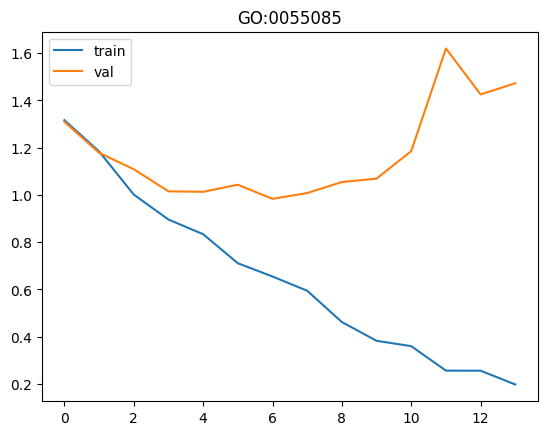


Training for GO:0043066  (GO_3A0043066.annotprot)
Total sequences: 6784, Positives: 190, Negatives: 6594
Train: 4748 sequences, 133 positive
Val  : 1018 sequences, 29 positive
Test : 1018 sequences, 28 positive
Total: 6784 sequences
  pos_weight = 34.70  (n_neg=4615, n_pos=133)


  Epoch 1: train=1.3667, val=1.3566


  Epoch 2: train=1.3620, val=1.3586


  Epoch 3: train=1.3379, val=1.3551


  Epoch 4: train=1.3328, val=1.3555


...

  Epoch 11: train=0.6332, val=2.0085


  Epoch 12: train=0.5139, val=1.6401


  Epoch 13: train=0.4837, val=1.9596


  Epoch 14: train=0.3513, val=2.1703


  Epoch 15: train=0.2883, val=2.3147
  Early stopping.
--- Test (GO:0043066) Accuracy 0.6061 ---
    Macro F1     0.4138
    Weighted F1  0.7311


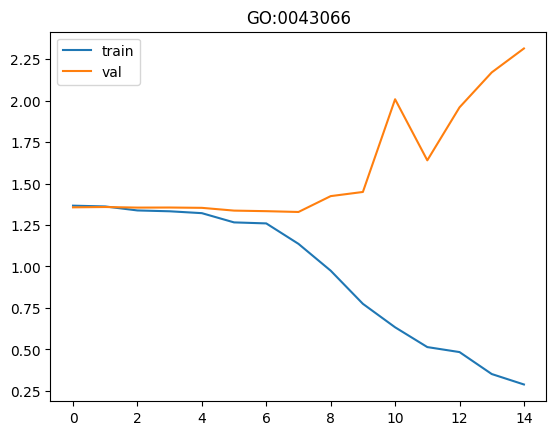

In [27]:
# Train one independent model per GO term — same architecture, same reuse
go_models = {}

for go_id, annotfile in GO_TERMS.items():
    model, test_ds = train_go_model(go_id, annotfile)
    go_models[go_id] = (model, test_ds)

In [28]:
# Read the final unlabeled test set — FASTA format
# (protein IDs in >header lines, sequences on the next line(s))

def read_fasta(fastafile):
    """Read a FASTA file and return a dict {protein_id: sequence}."""
    seqs = {}
    current_id = None
    current_seq = []
    with open(fastafile) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id is not None:
                    seqs[current_id] = ''.join(current_seq)
                current_id = line[1:].split()[0]  # take first word after >
                current_seq = []
            else:
                current_seq.append(line)
    if current_id is not None:
        seqs[current_id] = ''.join(current_seq)
    print(f"Loaded {len(seqs)} sequences from {fastafile}")
    return seqs

# Load it
test_fasta = read_fasta("test_set_filt.f")

Loaded 14765 sequences from test_set_filt.f


In [29]:
# Run each trained GO model on the 14,765 unlabeled test sequences
# and collect predictions

context_size = 1000

def predict_fasta(model, fasta_dict, context_size, device):
    """Run a trained model on sequences from read_fasta(), returns {id: pred_label}."""
    ids = list(fasta_dict.keys())
    seqs = list(fasta_dict.values())

    # Reuse SequenceDatasetOneHot — just pass dummy labels (all 0, not used)
    dummy_labels = [0] * len(seqs)
    ds = SequenceDatasetOneHot(seqs, dummy_labels, context_size)
    loader = DataLoader(ds, batch_size=32)

    model.eval()
    all_preds = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(int)
            all_preds.extend(preds)

    return {pid: pred for pid, pred in zip(ids, all_preds)}


# Predict for all 5 GO terms
for go_id, (model, _) in go_models.items():
    preds = predict_fasta(model, test_fasta, context_size, DEVICE)
    n_pos = sum(preds.values())
    print(f"{go_id}: {n_pos} proteins predicted positive out of {len(preds)}")

GO:0005739: 3044 proteins predicted positive out of 14765
GO:0007165: 3053 proteins predicted positive out of 14765
GO:0005576: 2863 proteins predicted positive out of 14765
GO:0055085: 1851 proteins predicted positive out of 14765
GO:0043066: 8093 proteins predicted positive out of 14765
